In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("Dataset for Data Analytics - Sheet1.csv")

# Display the first 5 rows
print(df.head())

# Display the last 5 rows
print(df.tail())

# Display the shape of the dataset
print(df.shape)

# Display the column names
print(df.columns)

# Display the data types
print(df.dtypes)

# Display summary information
print(df.info())

     OrderID        Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000  2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001  2024-08-23     C75739    Phone         2     151.35   
2  ORD200002  2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003  2023-10-15     C33540    Chair         1     273.19   
4  ORD200004  2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREE

In [2]:
# Check and Handle Missing Values

# Check missing values
print("Missing Values:")
print(df.isnull().sum())


Missing Values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


In [3]:

# Check missing percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("\nMissing Value Percentage:")
print(missing_percentage)

# Fill missing values in CouponCode
df["CouponCode"] = df["CouponCode"].fillna("NoCoupon")

# Verify missing values
print("\nMissing Values After Imputation:")
print(df.isnull().sum())


Missing Value Percentage:
OrderID             0.00
Date                0.00
CustomerID          0.00
Product             0.00
Quantity            0.00
UnitPrice           0.00
ShippingAddress     0.00
PaymentMethod       0.00
OrderStatus         0.00
TrackingNumber      0.00
ItemsInCart         0.00
CouponCode         25.75
ReferralSource      0.00
TotalPrice          0.00
dtype: float64

Missing Values After Imputation:
OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64


In [4]:
df_before = df.copy()
# Select numerical columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

print("Outlier Detection using IQR\n")

# Detect outliers for each numerical column
for col in numeric_columns:

    # Calculate Quartiles
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Calculate lower and upper bounds
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    # Count outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}")
    print(f"Lower Bound : {lower_bound:.2f}")
    print(f"Upper Bound : {upper_bound:.2f}")
    print(f"Number of Outliers : {len(outliers)}")
    print("-" * 50)

Outlier Detection using IQR

Quantity
Lower Bound : -1.00
Upper Bound : 7.00
Number of Outliers : 0
--------------------------------------------------
UnitPrice
Lower Bound : -317.20
Upper Bound : 1024.83
Number of Outliers : 0
--------------------------------------------------
ItemsInCart
Lower Bound : -0.50
Upper Bound : 11.50
Number of Outliers : 0
--------------------------------------------------
TotalPrice
Lower Bound : -1341.41
Upper Bound : 3330.41
Number of Outliers : 8
--------------------------------------------------


In [5]:
# Select numerical columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Apply capping
for col in numeric_columns:

    # Calculate Quartiles
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Calculate bounds
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    # Cap the outliers
    df[col] = df[col].clip(lower=lower_bound,
                           upper=upper_bound)

print("Outliers have been neutralized successfully!")

Outliers have been neutralized successfully!


In [6]:
print("Checking Outliers After Capping\n")

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers remaining")

Checking Outliers After Capping

Quantity: 0 outliers remaining
UnitPrice: 0 outliers remaining
ItemsInCart: 0 outliers remaining
TotalPrice: 0 outliers remaining


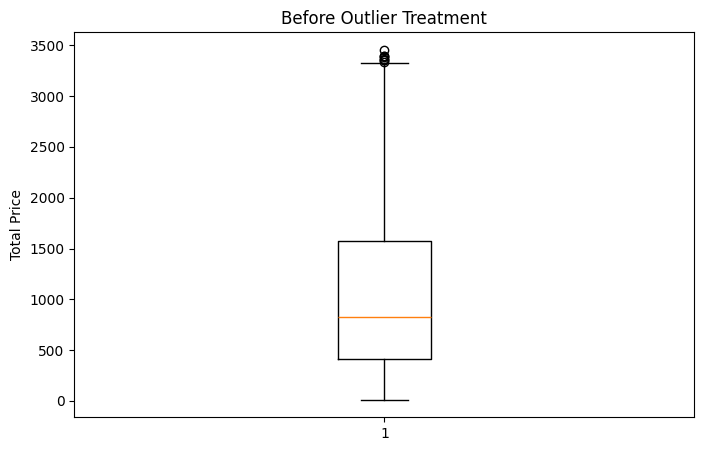

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(df_before["TotalPrice"])
plt.title("Before Outlier Treatment")
plt.ylabel("Total Price")
plt.show()

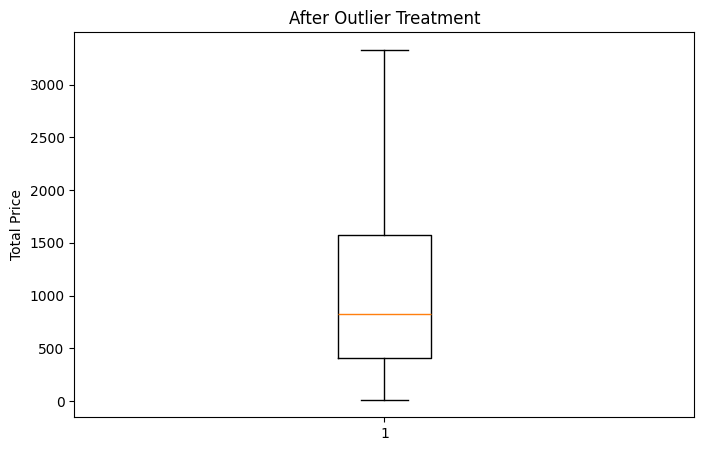

In [8]:
plt.figure(figsize=(8,5))
plt.boxplot(df["TotalPrice"])
plt.title("After Outlier Treatment")
plt.ylabel("Total Price")
plt.show()

In [9]:

# Feature Engineering

# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# ------------------------------------------
# 1. Order Month
# ------------------------------------------
df["OrderMonth"] = df["Date"].dt.month

# ------------------------------------------
# 2. Order Year
# ------------------------------------------
df["OrderYear"] = df["Date"].dt.year

# ------------------------------------------
# 3. Average Price Per Item
# Formula = TotalPrice / Quantity
# ------------------------------------------
df["AveragePricePerItem"] = df["TotalPrice"] / df["Quantity"]

# ------------------------------------------
# 4. Cart Utilization
# Formula = Quantity / ItemsInCart
# ------------------------------------------
df["CartUtilization"] = df["Quantity"] / df["ItemsInCart"]

# ------------------------------------------
# 5. Discount Used
# 1 = Coupon Used
# 0 = No Coupon
# ------------------------------------------
df["DiscountUsed"] = df["CouponCode"].apply(
    lambda x: 0 if x == "NoCoupon" else 1
)

df["AveragePricePerItem"] = df["AveragePricePerItem"].round(2)
df["CartUtilization"] = df["CartUtilization"].round(2)

# Display first five rows
print(df.head())

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  OrderMonth  OrderYear  \
0     SAVE10      Instagram     2853.10           1       2023   
1     SA

In [10]:
# Display only the newly created features
print(df[[
    "OrderMonth",
    "OrderYear",
    "AveragePricePerItem",
    "CartUtilization",
    "DiscountUsed"
]].head())

   OrderMonth  OrderYear  AveragePricePerItem  CartUtilization  DiscountUsed
0           1       2023               570.62             0.71             1
1           8       2024               151.35             0.67             1
2           2       2024               550.68             0.62             1
3          10       2023               273.19             0.20             1
4           5       2025               626.01             0.50             1


In [11]:
# Encode Categorical Variables

# Columns to encode
categorical_columns = [
    "Product",
    "PaymentMethod",
    "OrderStatus",
    "CouponCode",
    "ReferralSource"
]

# Apply One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

# Convert boolean columns (True/False) to integers (1/0)
bool_columns = df.select_dtypes(include="bool").columns
df[bool_columns] = df[bool_columns].astype(int)

print("Categorical variables encoded successfully!")

# Display the first five rows
print(df.head())

Categorical variables encoded successfully!
     OrderID       Date CustomerID  Quantity  UnitPrice ShippingAddress  \
0  ORD200000 2023-01-04     C72649         5     570.62     928 Main St   
1  ORD200001 2024-08-23     C75739         2     151.35     823 Main St   
2  ORD200002 2024-02-27     C81728         5     550.68     512 Main St   
3  ORD200003 2023-10-15     C33540         1     273.19     275 Main St   
4  ORD200004 2025-05-08     C81840         4     626.01     668 Main St   

  TrackingNumber  ItemsInCart  TotalPrice  OrderMonth  ...  \
0    TRK37947903            7     2853.10           1  ...   
1    TRK91186779            3      302.70           8  ...   
2    TRK42903982            8     2753.40           2  ...   
3    TRK62788070            5      273.19          10  ...   
4    TRK29241424            8     2504.04           5  ...   

   OrderStatus_Pending  OrderStatus_Returned  OrderStatus_Shipped  \
0                    0                     0                   

In [12]:
print(df.columns)

Index(['OrderID', 'Date', 'CustomerID', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'TrackingNumber', 'ItemsInCart', 'TotalPrice',
       'OrderMonth', 'OrderYear', 'AveragePricePerItem', 'CartUtilization',
       'DiscountUsed', 'Product_Desk', 'Product_Laptop', 'Product_Monitor',
       'Product_Phone', 'Product_Printer', 'Product_Tablet',
       'PaymentMethod_Credit Card', 'PaymentMethod_Debit Card',
       'PaymentMethod_Gift Card', 'PaymentMethod_Online',
       'OrderStatus_Delivered', 'OrderStatus_Pending', 'OrderStatus_Returned',
       'OrderStatus_Shipped', 'CouponCode_NoCoupon', 'CouponCode_SAVE10',
       'CouponCode_WINTER15', 'ReferralSource_Facebook',
       'ReferralSource_Google', 'ReferralSource_Instagram',
       'ReferralSource_Referral'],
      dtype='object')


In [14]:
# Save the Cleaned Dataset

df.to_csv("Cleaned Data Analytics - Sheet1.csv", index=False)

print("dataset saved successfully!")

dataset saved successfully!
